In [ ]:
Environmental Setup

In [ ]:
#numpy, pandas, PIL, matplotlib, ...
#pip install -q gradio

In [4]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


In [5]:
!wget https://isic-archive.s3.amazonaws.com/dois/10.34970-648456/milk10k.zip
!unzip milk10k.zip -d milk10k


Streaming output truncated to the last 5000 lines.
 extracting: milk10k/images/ISIC_7382332.jpg  
 extracting: milk10k/images/ISIC_0907354.jpg  
 extracting: milk10k/images/ISIC_8188045.jpg  
 extracting: milk10k/images/ISIC_9320577.jpg  
 extracting: milk10k/images/ISIC_5828606.jpg  
 extracting: milk10k/images/ISIC_5543636.jpg  
 extracting: milk10k/images/ISIC_7176466.jpg  
 extracting: milk10k/images/ISIC_1718501.jpg  
 extracting: milk10k/images/ISIC_4328393.jpg  
 extracting: milk10k/images/ISIC_1576697.jpg  
 extracting: milk10k/images/ISIC_1350051.jpg  
 extracting: milk10k/images/ISIC_2554103.jpg  
 extracting: milk10k/images/ISIC_5570317.jpg  
 extracting: milk10k/images/ISIC_2214683.jpg  
 extracting: milk10k/images/ISIC_3014783.jpg  
 extracting: milk10k/images/ISIC_4371553.jpg  
 extracting: milk10k/images/ISIC_3564212.jpg  
 extracting: milk10k/images/ISIC_4245317.jpg  
 extracting: milk10k/images/ISIC_7661066.jpg  
 extracting: milk10k/images/ISIC_3418246.jpg  
 extracti

In [8]:
from pathlib import Path
DATA_DIR = Path("milk10k")
IMG_DIR = DATA_DIR / "images"

#Milk 10k has around 10k images
n_images = len(list((IMG_DIR.glob("*.jpg"))))
print(f"Number of images: {n_images}")

Number of images: 10480


In [10]:
path_metadata = DATA_DIR / "metadata.csv"
df_metadata = pd.read_csv(path_metadata)
df_metadata.head()

gt = pd.read_csv(DATA_DIR / "supplements" / "training_gt.csv")
gt.head()

#
#

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0,1,0,0,0,0,0,0,0,0,0
1,IL_0003176,0,1,0,0,0,0,0,0,0,0,0
2,IL_0004688,0,1,0,0,0,0,0,0,0,0,0
3,IL_0005081,0,0,0,0,0,0,0,0,0,1,0
4,IL_0006177,0,1,0,0,0,0,0,0,0,0,0


In [12]:
len(df_metadata)
df_metadata.shape


(10480, 17)

In [13]:
len(gt)
gt.shape


(5240, 12)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [17]:
df_metadata.columns

Index(['isic_id', 'attribution', 'copyright_license', 'age_approx',
       'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy',
       'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4',
       'diagnosis_confirm_type', 'image_manipulation', 'image_type',
       'lesion_id', 'melanocytic', 'sex'],
      dtype='object')

In [19]:
df_metadata.diagnosis_1.unique()

array(['Malignant', 'Benign', 'Indeterminate'], dtype=object)

In [20]:
df_metadata.diagnosis_1.value_counts()

,count
diagnosis_1,
Malignant,7268
Benign,2966
Indeterminate,246


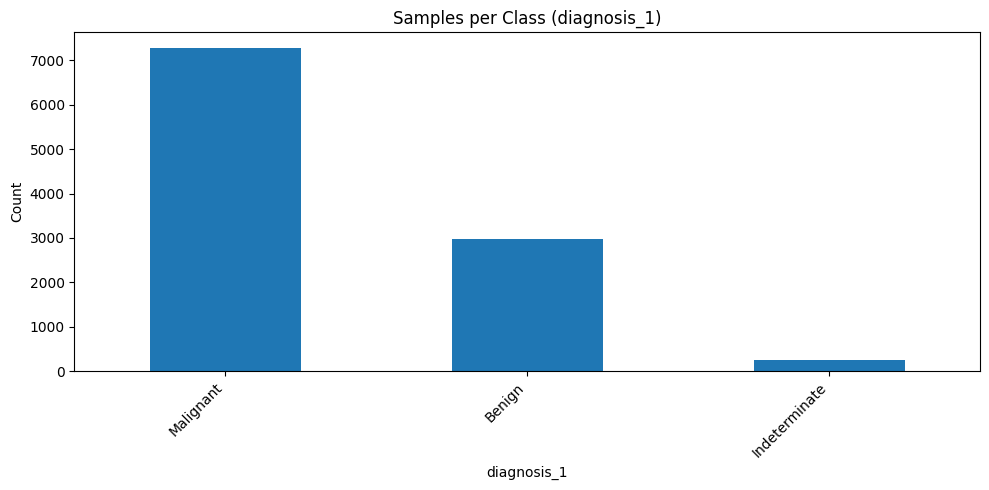

In [21]:
# --- EDA ---

# 1. Number of samples per class (diagnosis_1) - bar plot
fig, ax = plt.subplots(figsize=(10, 5))
df_metadata['diagnosis_1'].value_counts().plot(kind='bar', ax=ax)
ax.set_title('Samples per Class (diagnosis_1)')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



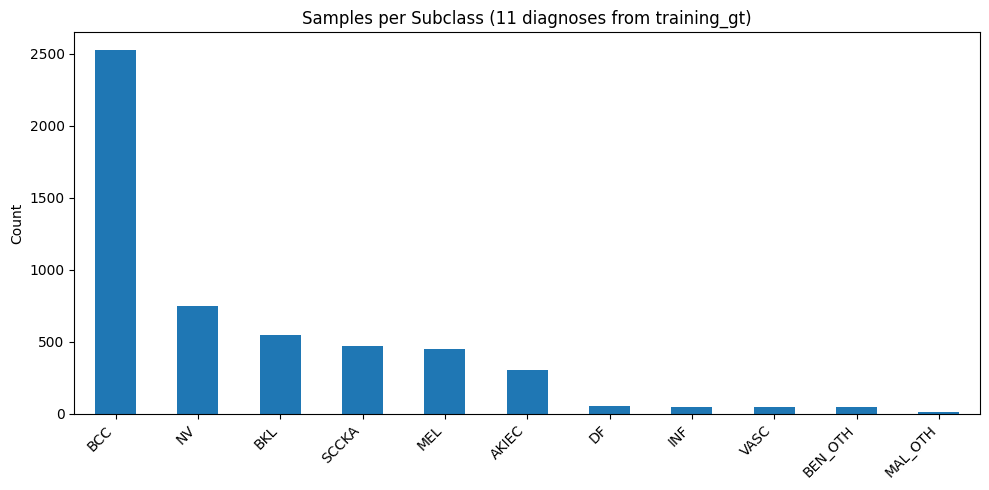

In [22]:

# 2. Number of samples per subclass (11 diagnosis) - bar plot
# Merge metadata with ground truth to get the 11 diagnosis columns
gt_cols = gt.columns.drop('lesion_id')  # all columns except lesion_id
fig, ax = plt.subplots(figsize=(10, 5))
gt[gt_cols].sum().sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Samples per Subclass (11 diagnoses from training_gt)')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

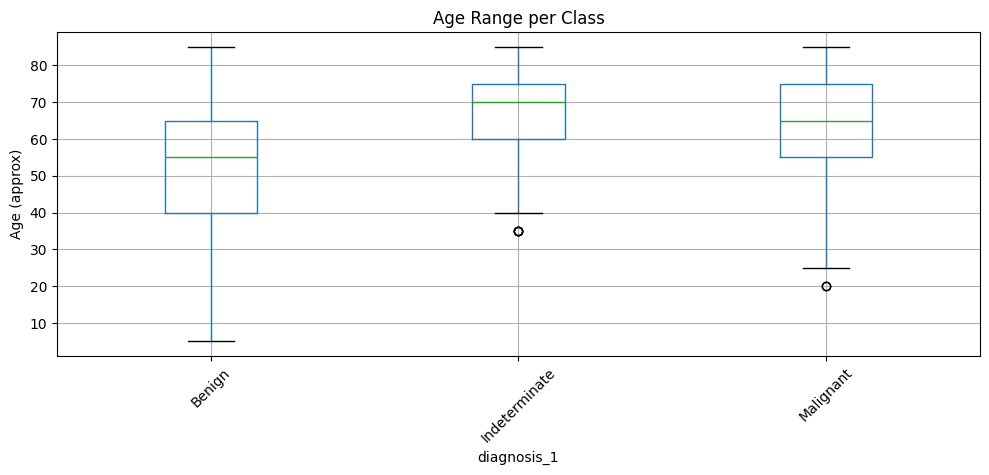

In [23]:


# 3. Age range per class
fig, ax = plt.subplots(figsize=(10, 5))
df_metadata.boxplot(column='age_approx', by='diagnosis_1', ax=ax, rot=45)
ax.set_title('Age Range per Class')
ax.set_ylabel('Age (approx)')
fig.suptitle('')  # remove auto title
plt.tight_layout()
plt.show()


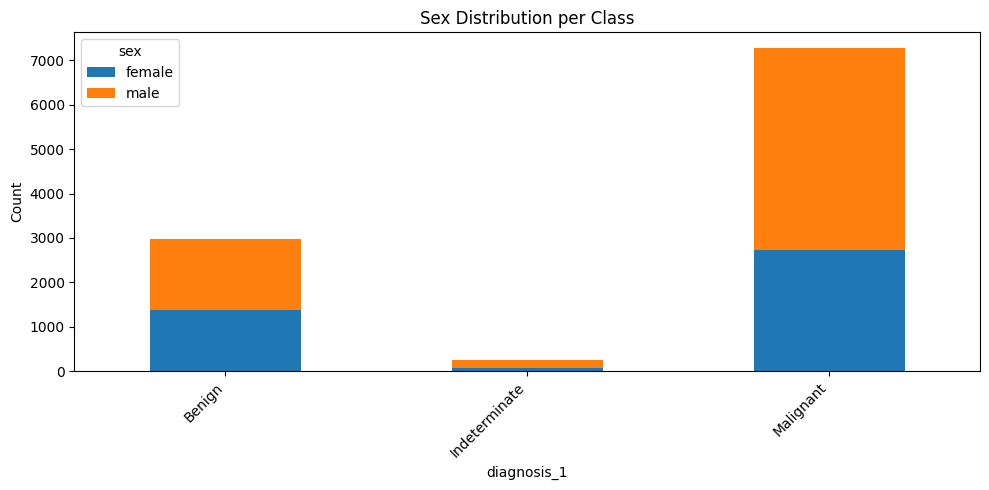

In [24]:

# 4. Sex distribution per class
sex_class = df_metadata.groupby(['diagnosis_1', 'sex']).size().unstack(fill_value=0)
sex_class.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.title('Sex Distribution per Class')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: >

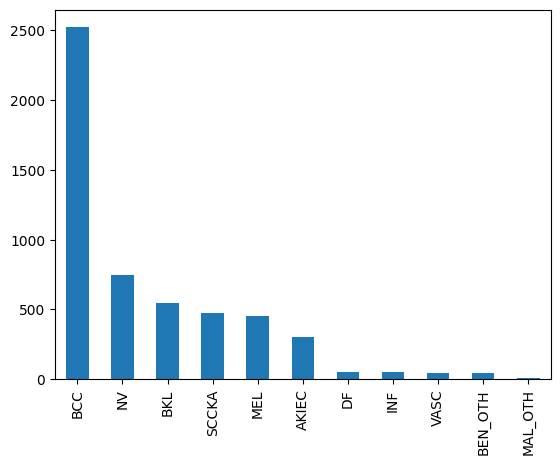

In [28]:
counts = gt.drop(columns="lesion_id").sum().sort_values(ascending=False)
counts

counts.plot(kind="bar")

milk10k/images/ISIC_0051817.jpg


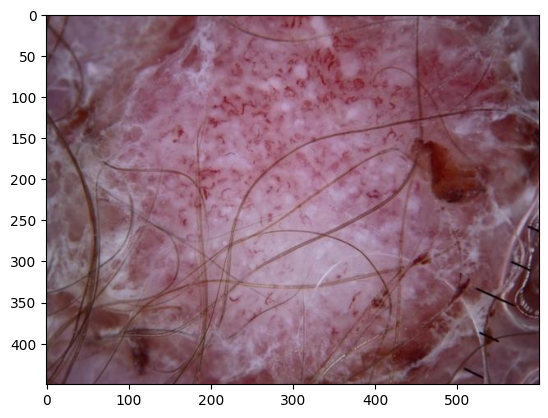

In [26]:
# PIL (Python Image Library)
# df_metadata.isic_id - contains the name of the image
# Path of the first image
row = df_metadata.iloc[0]
img_path = IMG_DIR / f'{row["isic_id"]}.jpg'
print(img_path)
img = Image.open(img_path)
plt.imshow(img)

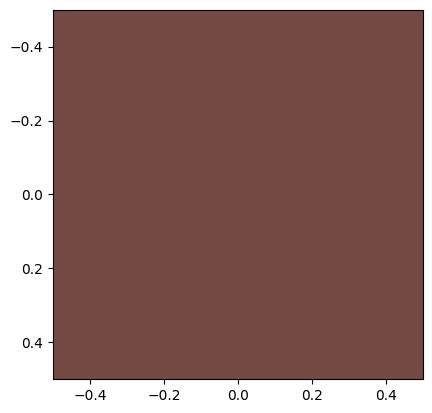

In [27]:
arr = np.array(img)
arr.shape # 3 number of channels --> RGB
arr[0,0]
plt.imshow(arr[0:1,0:1])

=== Metadata ===
Shape: (10480, 17)
Columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

=== Ground Truth ===
Shape: (5240, 12)
Columns: ['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

Number of images on disk: 10480

Missing values in metadata:
isic_id                       0
attribution                   0
copyright_license             0
age_approx                   40
anatom_site_general        3912
anatom_site_special       10274
concomitant_biopsy            0
diagnosis_1                   0
diagnosis_2                   0
diagnosis_3                 158
diagnosis_4                8958
diagnosis_confirm_type        0
image_manipulation            0
image_type                    0
lesion_

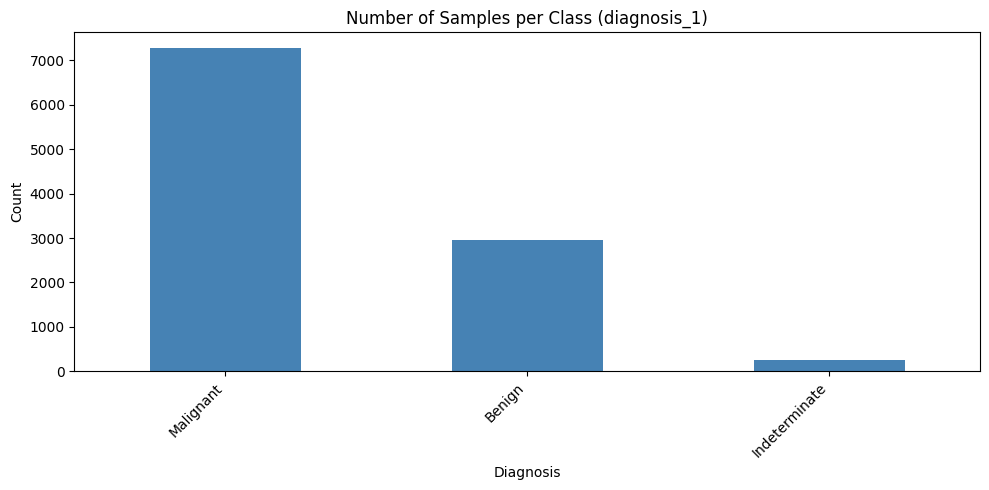

BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
dtype: int64


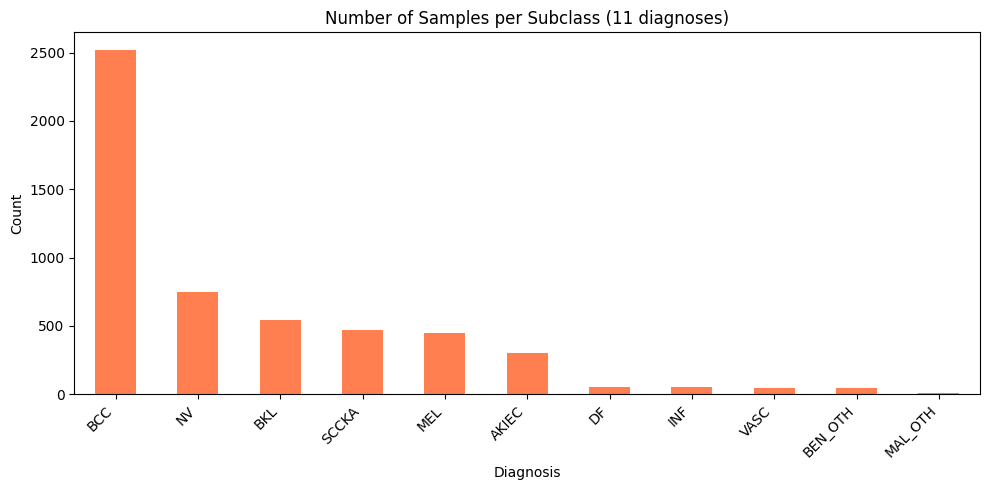

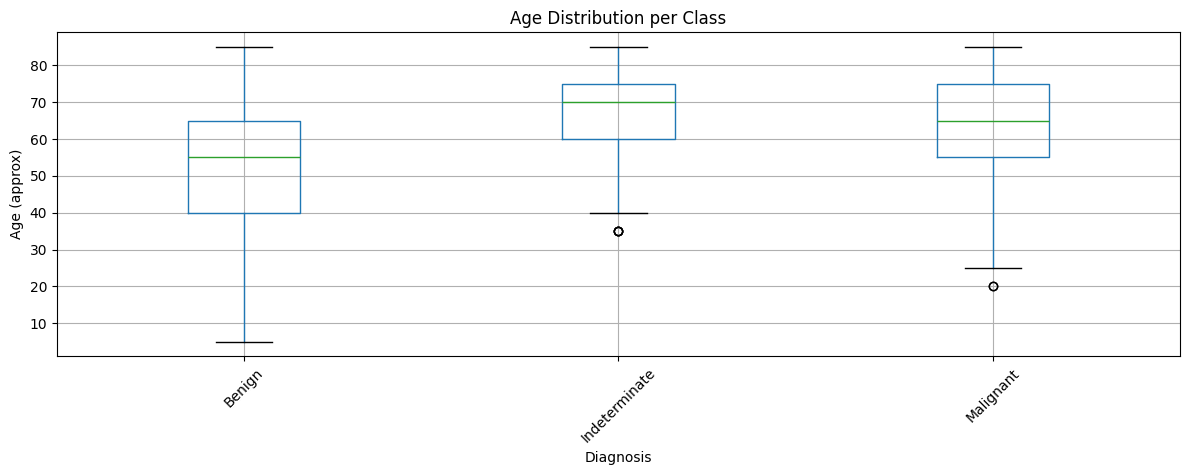

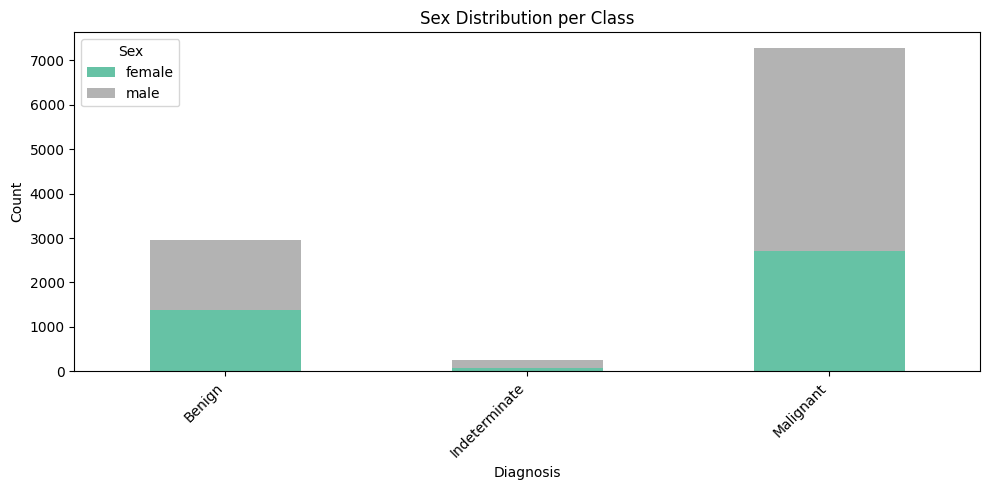

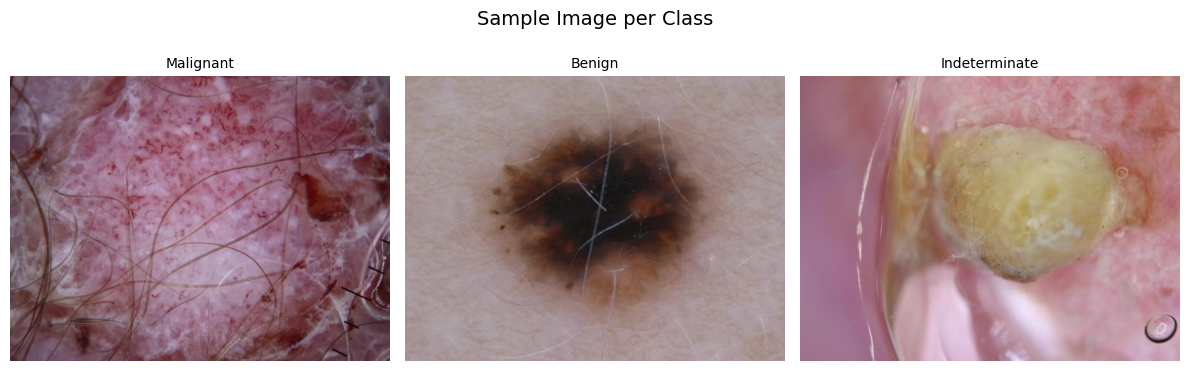

Most common image sizes: [((600, 450), 500)]


In [29]:

# EXPLORATORY DATA ANALYSIS (EDA) — MILK10k Dataset


# --- Clinical Task Explanation ---
# The MILK10k dataset contains ~10,480 dermoscopic images of skin lesions
# from the ISIC archive. The clinical goal is to classify skin lesions
# into diagnostic categories (e.g., melanoma, basal cell carcinoma, etc.)
# to assist dermatologists in early detection of skin cancer.
# This is a multi-class classification problem with 11 diagnosis labels
# provided in the ground truth file (training_gt.csv).


# 1. Dataset Overview

print("=== Metadata ===")
print(f"Shape: {df_metadata.shape}")
print(f"Columns: {list(df_metadata.columns)}")
print(f"\n=== Ground Truth ===")
print(f"Shape: {gt.shape}")
print(f"Columns: {list(gt.columns)}")
print(f"\nNumber of images on disk: {n_images}")
print(f"\nMissing values in metadata:\n{df_metadata.isnull().sum()}")


# 2. Samples per class (diagnosis_1) — bar plot

fig, ax = plt.subplots(figsize=(10, 5))
df_metadata['diagnosis_1'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Number of Samples per Class (diagnosis_1)')
ax.set_ylabel('Count')
ax.set_xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 3. Samples per subclass (11 diagnoses from training_gt) — bar plot

gt_counts = gt.drop(columns="lesion_id").sum().sort_values(ascending=False)
print(gt_counts)

fig, ax = plt.subplots(figsize=(10, 5))
gt_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Number of Samples per Subclass (11 diagnoses)')
ax.set_ylabel('Count')
ax.set_xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 4. Age range per class — box plot

fig, ax = plt.subplots(figsize=(12, 5))
df_metadata.boxplot(column='age_approx', by='diagnosis_1', ax=ax, rot=45)
ax.set_title('Age Distribution per Class')
ax.set_ylabel('Age (approx)')
ax.set_xlabel('Diagnosis')
fig.suptitle('')
plt.tight_layout()
plt.show()


# 5. Sex distribution per class — stacked bar

sex_class = df_metadata.groupby(['diagnosis_1', 'sex']).size().unstack(fill_value=0)
sex_class.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2')
plt.title('Sex Distribution per Class')
plt.ylabel('Count')
plt.xlabel('Diagnosis')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()


# 6. Sample images per class

classes = df_metadata['diagnosis_1'].unique()
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    sample = df_metadata[df_metadata['diagnosis_1'] == cls].iloc[0]
    img_path = IMG_DIR / f'{sample["isic_id"]}.jpg'
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Image per Class', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Image size distribution

from collections import Counter
sizes = []
for f in list(IMG_DIR.glob("*.jpg"))[:500]:  # sample 500 for speed
    with Image.open(f) as im:
        sizes.append(im.size)
size_counts = Counter(sizes)
print(f"Most common image sizes: {size_counts.most_common(5)}")